# Crank–Nicolson Method for the 1D Time-Dependent Schrödinger Equation

In this notebook, we use the Crank–Nicolson method to evolve a one-dimensional quantum Gaussian wavepacket.

The goal is to solve the time-dependent Schrödinger equation

$$
i\hbar \frac{\partial \psi(x,t)}{\partial t}
=
\hat H \psi(x,t),
$$

where the Hamiltonian is

$$
\hat H
=
-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}+V(x).
$$

For this first example, we use a free particle, so

$$
V(x)=0.
$$

Physically, this means the wavepacket moves freely without encountering a barrier, well, or force field.

## 1. The Crank–Nicolson idea

The exact quantum time evolution is

$$
\psi(t+\Delta t)
=
e^{-i\hat H\Delta t/\hbar}\psi(t).
$$

Crank–Nicolson approximates this using a symmetric average between the current time step and the future time step.

Starting from

$$
i\hbar \frac{\partial \psi}{\partial t}=\hat H\psi,
$$

we write

$$
\frac{\psi^{n+1}-\psi^n}{\Delta t}
=
-\frac{i}{\hbar}\hat H
\left(\frac{\psi^{n+1}+\psi^n}{2}\right).
$$

Rearranging gives

$$
\left(I+\frac{i\Delta t}{2\hbar}\hat H\right)\psi^{n+1}
=
\left(I-\frac{i\Delta t}{2\hbar}\hat H\right)\psi^n.
$$

This is the central update equation:

$$
A\psi^{n+1}=B\psi^n,
$$

where

$$
A=I+\frac{i\Delta t}{2\hbar}H,
\qquad
B=I-\frac{i\Delta t}{2\hbar}H.
$$

At each time step, we solve a linear system for the future wavefunction.

In [1]:
import numpy as np
from scipy.sparse import diags, identity
from scipy.sparse.linalg import splu
import matplotlib.pyplot as plt

# Make plots display nicely in the notebook
%matplotlib inline

## 2. Define physical constants

To keep the first example simple, we work in dimensionless units:

$$
\hbar=1,
\qquad
m=1.
$$

This does not change the structure of the method. It only avoids carrying physical constants through every line of code.

In [2]:
# Physical constants in dimensionless units
hbar = 1.0
m = 1.0

## 3. Create the spatial grid

We replace the continuous coordinate $x$ by a discrete grid:

$$
x_j=x_{\min}+j\Delta x,
$$

where

$$
\Delta x=\frac{x_{\max}-x_{\min}}{N-1}.
$$

The wavefunction becomes a vector:

$$
\psi(x,t)\rightarrow
\begin{bmatrix}
\psi_0(t)\\
\psi_1(t)\\
\psi_2(t)\\
\vdots\\
\psi_{N-1}(t)
\end{bmatrix}.
$$

Here, $\psi_j(t)$ means the value of the wavefunction at the grid point $x_j$.

In [3]:
# Spatial grid
N = 1000
x_min = -50.0
x_max = 50.0

x = np.linspace(x_min, x_max, N)
dx = x[1] - x[0]

print(f"Number of grid points: {N}")
print(f"dx = {dx:.5f}")

Number of grid points: 1000
dx = 0.10010


## 4. Choose the time step

We discretize time as

$$
t_n=n\Delta t.
$$

The Crank–Nicolson method is stable for this quantum evolution when the Hamiltonian is Hermitian, but stability does not automatically mean accuracy.

A smaller $\Delta t$ usually gives a more accurate time evolution.

In [4]:
# Time step
dt = 0.01

print(f"dt = {dt}")

dt = 0.01


## 5. Define the potential

For a free particle,

$$
V(x)=0.
$$

So the Hamiltonian is purely kinetic:

$$
\hat H
=
-\frac{\hbar^2}{2m}\frac{\partial^2}{\partial x^2}.
$$

Later, we can replace this with a harmonic oscillator potential,

$$
V(x)=\frac{1}{2}m\omega^2x^2,
$$

or a barrier, well, or any potential we want.

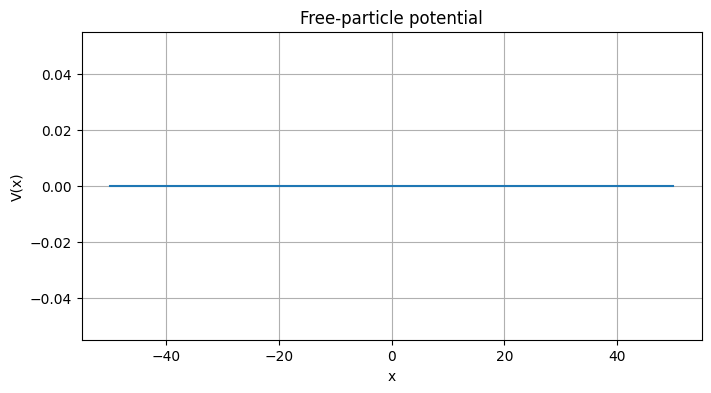

In [5]:
# Free-particle potential
V = np.zeros(N)

plt.figure(figsize=(8, 4))
plt.plot(x, V)
plt.xlabel("x")
plt.ylabel("V(x)")
plt.title("Free-particle potential")
plt.grid(True)
plt.show()

## 6. Discretize the Hamiltonian

The second derivative is approximated using the central difference formula:

$$
\frac{\partial^2\psi}{\partial x^2}\bigg|_{x=x_j}
\approx
\frac{\psi_{j+1}-2\psi_j+\psi_{j-1}}{(\Delta x)^2}.
$$

Substitute this into the Hamiltonian:

$$
(H\psi)_j
=
-\frac{\hbar^2}{2m}
\frac{\psi_{j+1}-2\psi_j+\psi_{j-1}}{(\Delta x)^2}
+V_j\psi_j.
$$

Expanding the terms gives

$$
(H\psi)_j
=
-\frac{\hbar^2}{2m(\Delta x)^2}\psi_{j-1}
+
\left(\frac{\hbar^2}{m(\Delta x)^2}+V_j\right)\psi_j
-\frac{\hbar^2}{2m(\Delta x)^2}\psi_{j+1}.
$$

So the Hamiltonian matrix is tridiagonal:

$$
H_{j,j}=\frac{\hbar^2}{m(\Delta x)^2}+V_j,
$$

$$
H_{j,j-1}=H_{j,j+1}
=
-\frac{\hbar^2}{2m(\Delta x)^2}.
$$

A tridiagonal matrix is perfect here because sparse matrix methods can solve the system efficiently.

In [6]:
# Hamiltonian matrix entries
main_diag = hbar**2 / (m * dx**2) + V
off_diag = -hbar**2 / (2 * m * dx**2) * np.ones(N - 1)

# Sparse tridiagonal Hamiltonian matrix
H = diags(
    [off_diag, main_diag, off_diag],
    offsets=[-1, 0, 1],
    format="csc"
)

print(H)
print(f"Hamiltonian shape: {H.shape}")

  (1, 0)	-49.900050000000036
  (0, 0)	99.80010000000007
  (2, 1)	-49.900050000000036
  (1, 1)	99.80010000000007
  (0, 1)	-49.900050000000036
  (3, 2)	-49.900050000000036
  (2, 2)	99.80010000000007
  (1, 2)	-49.900050000000036
  (4, 3)	-49.900050000000036
  (3, 3)	99.80010000000007
  (2, 3)	-49.900050000000036
  (5, 4)	-49.900050000000036
  (4, 4)	99.80010000000007
  (3, 4)	-49.900050000000036
  (6, 5)	-49.900050000000036
  (5, 5)	99.80010000000007
  (4, 5)	-49.900050000000036
  (7, 6)	-49.900050000000036
  (6, 6)	99.80010000000007
  (5, 6)	-49.900050000000036
  (8, 7)	-49.900050000000036
  (7, 7)	99.80010000000007
  (6, 7)	-49.900050000000036
  (9, 8)	-49.900050000000036
  (8, 8)	99.80010000000007
  :	:
  (991, 991)	99.80010000000007
  (990, 991)	-49.900050000000036
  (993, 992)	-49.900050000000036
  (992, 992)	99.80010000000007
  (991, 992)	-49.900050000000036
  (994, 993)	-49.900050000000036
  (993, 993)	99.80010000000007
  (992, 993)	-49.900050000000036
  (995, 994)	-49.900050000000

## 7. Build the Crank–Nicolson matrices

The update equation is

$$
\left(I+\frac{i\Delta t}{2\hbar}H\right)\psi^{n+1}
=
\left(I-\frac{i\Delta t}{2\hbar}H\right)\psi^n.
$$

Define

$$
A=I+\frac{i\Delta t}{2\hbar}H,
$$

$$
B=I-\frac{i\Delta t}{2\hbar}H.
$$

Then the numerical evolution is

$$
A\psi^{n+1}=B\psi^n.
$$

At every time step, the right-hand side $B\psi^n$ is known, and we solve for $\psi^{n+1}$.

In [7]:
# Identity matrix
I = identity(N, format="csc")

# Crank-Nicolson matrices
A = I + 1j * dt / (2 * hbar) * H
B = I - 1j * dt / (2 * hbar) * H

print(f"A shape: {A.shape}")
print(f"B shape: {B.shape}")

A shape: (1000, 1000)
B shape: (1000, 1000)


## 8. Factorize the matrix $A$

Since $A$ does not change with time for a time-independent Hamiltonian, we factorize it once.

This is much faster than solving from scratch at every time step.

Instead of computing

$$
A^{-1},
$$

we use an LU factorization and solve

$$
A\psi^{n+1}=b,
$$

where

$$
b=B\psi^n.
$$

Numerically, solving a matrix equation is better than explicitly forming the inverse.

In [8]:
# Factorize A once for efficient repeated solves
A_lu = splu(A)

print("LU factorization complete.")

LU factorization complete.


## 9. Create the initial Gaussian wavepacket

We choose an initial wavefunction of the form

$$
\psi(x,0)
=
\exp\left[-\frac{(x-x_0)^2}{2\sigma^2}\right]
\exp(ik_0x).
$$

The first factor is a Gaussian envelope centered at $x_0$:

$$
\exp\left[-\frac{(x-x_0)^2}{2\sigma^2}\right].
$$

The second factor is a complex plane-wave phase:

$$
\exp(ik_0x).
$$

The parameter $k_0$ controls the average momentum:

$$
p_0=\hbar k_0.
$$

Because $k_0>0$, the packet should move to the right.

In [9]:
# Initial Gaussian wavepacket parameters
x0 = -10.0
sigma = 2.0
k0 = 2.0

# Complex initial wavefunction
psi = np.exp(-(x - x0)**2 / (2 * sigma**2)) * np.exp(1j * k0 * x)

# Normalize the wavefunction
norm = np.sqrt(np.sum(np.abs(psi)**2) * dx)
psi = psi / norm

# Save a copy for comparison later
psi_initial = psi.copy()

print(f"Initial normalization = {np.sum(np.abs(psi)**2) * dx:.12f}")

Initial normalization = 1.000000000000


## 10. Plot the initial probability density

The wavefunction $\psi$ is complex, so the physically meaningful probability density is

$$
|\psi(x,t)|^2.
$$

The normalization condition is

$$
\int |\psi(x,t)|^2\,dx=1.
$$

On the grid, this becomes

$$
\sum_j |\psi_j^n|^2\Delta x\approx 1.
$$

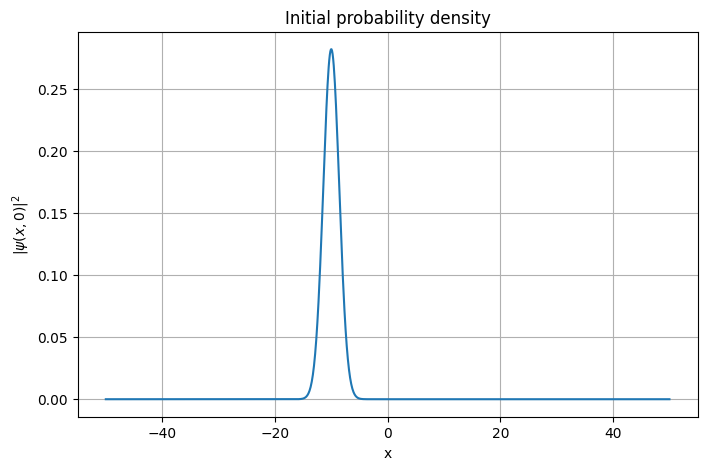

In [10]:
plt.figure(figsize=(8, 5))
plt.plot(x, np.abs(psi_initial)**2)
plt.xlabel("x")
plt.ylabel(r"$|\psi(x,0)|^2$")
plt.title("Initial probability density")
plt.grid(True)
plt.show()

## 11. Time evolution loop

At each time step, we compute

$$
b=B\psi^n,
$$

then solve

$$
A\psi^{n+1}=b.
$$

This gives

$$
\psi^{n+1}=A^{-1}B\psi^n,
$$

but we never explicitly calculate $A^{-1}$.

For this example, we evolve for

$$
N_t=1000
$$

time steps, so the final time is

$$
t_{\mathrm{final}}=N_t\Delta t=1000(0.01)=10.
$$

For a free particle, the group velocity is approximately

$$
v_g=\frac{\hbar k_0}{m}.
$$

With $\hbar=1$, $m=1$, and $k_0=2$,

$$
v_g=2.
$$

So the center should move roughly from $x=-10$ to

$$
x\approx -10+2(10)=10.
$$

In [11]:
# Number of time steps
num_steps = 1000

# Store normalization values to check probability conservation
norm_history = []

for n in range(num_steps):
    # Right-hand side of the Crank-Nicolson equation
    b = B @ psi
    
    # Solve A psi^{n+1} = b
    psi = A_lu.solve(b)
    
    # Track normalization
    probability = np.sum(np.abs(psi)**2) * dx
    norm_history.append(probability)

print(f"Final time = {num_steps * dt:.3f}")
print(f"Final normalization = {np.sum(np.abs(psi)**2) * dx:.12f}")

Final time = 10.000
Final normalization = 1.000000000000


## 12. Plot the final probability density

Now we plot

$$
|\psi(x,t_{\mathrm{final}})|^2.
$$

For a free particle, the wavepacket should move to the right and spread out.

The spreading happens because the Gaussian is not made of one exact momentum value. It contains a range of momenta. Different momentum components move with different phases, causing the packet to broaden over time.

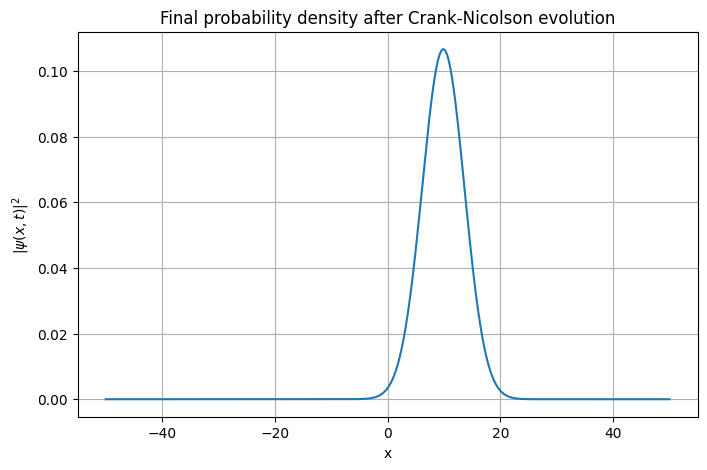

In [12]:
plt.figure(figsize=(8, 5))
plt.plot(x, np.abs(psi)**2)
plt.xlabel("x")
plt.ylabel(r"$|\psi(x,t)|^2$")
plt.title("Final probability density after Crank-Nicolson evolution")
plt.grid(True)
plt.show()

## 13. Compare initial and final wavepackets

This plot makes the physics easier to see.

Initially, the packet is centered near

$$
x_0=-10.
$$

After evolving to $t=10$, it should be centered near

$$
x\approx 10.
$$

It should also be wider because a free quantum wavepacket spreads.

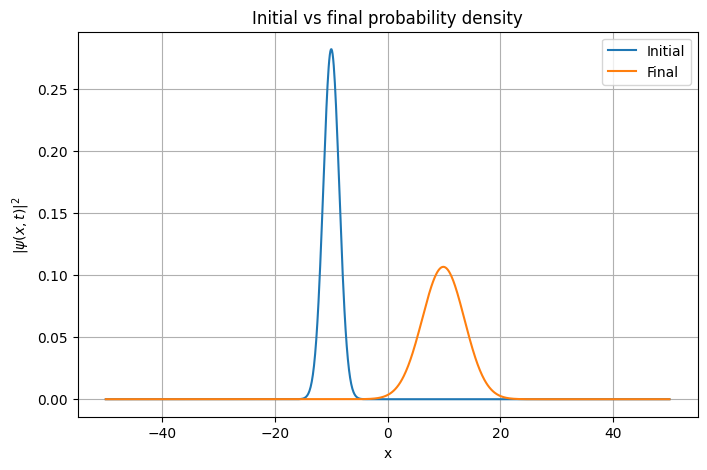

In [13]:
plt.figure(figsize=(8, 5))
plt.plot(x, np.abs(psi_initial)**2, label="Initial")
plt.plot(x, np.abs(psi)**2, label="Final")
plt.xlabel("x")
plt.ylabel(r"$|\psi(x,t)|^2$")
plt.title("Initial vs final probability density")
plt.legend()
plt.grid(True)
plt.show()

## 14. Check probability conservation

For quantum mechanics, total probability should remain equal to one:

$$
\sum_j |\psi_j^n|^2\Delta x\approx 1.
$$

Crank–Nicolson is especially useful for the Schrödinger equation because, for a Hermitian Hamiltonian, it gives a unitary time-stepping operator:

$$
U_{\mathrm{CN}}
=
\left(I+\frac{i\Delta t}{2\hbar}H\right)^{-1}
\left(I-\frac{i\Delta t}{2\hbar}H\right).
$$

A unitary update preserves the norm of the wavefunction.

In floating-point arithmetic, the norm may drift by tiny numerical roundoff amounts, but it should stay extremely close to 1.

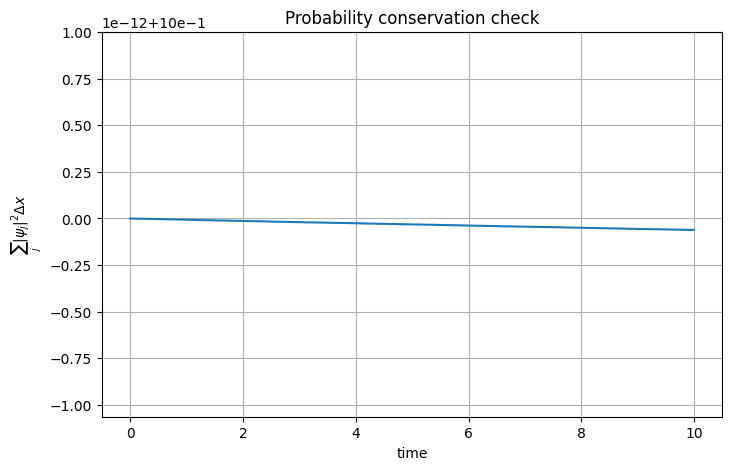

Minimum normalization: 1.000000000000
Maximum normalization: 1.000000000000
Final normalization:   1.000000000000


In [14]:
plt.figure(figsize=(8, 5))
plt.plot(np.arange(num_steps) * dt, norm_history)
plt.xlabel("time")
plt.ylabel(r"$\sum_j |\psi_j|^2 \Delta x$")
plt.title("Probability conservation check")
plt.grid(True)
plt.show()

print(f"Minimum normalization: {np.min(norm_history):.12f}")
print(f"Maximum normalization: {np.max(norm_history):.12f}")
print(f"Final normalization:   {norm_history[-1]:.12f}")

## 15. Estimate the wavepacket center

The expectation value of position is

$$
\langle x\rangle
=
\int x|\psi(x,t)|^2\,dx.
$$

On the grid, this becomes

$$
\langle x\rangle
\approx
\sum_j x_j |\psi_j|^2\Delta x.
$$

For this free wavepacket, we expect the center to move approximately as

$$
\langle x\rangle(t)
\approx
x_0+\frac{\hbar k_0}{m}t.
$$

In [15]:
x_expect_initial = np.sum(x * np.abs(psi_initial)**2) * dx
x_expect_final = np.sum(x * np.abs(psi)**2) * dx

expected_classical_center = x0 + (hbar * k0 / m) * (num_steps * dt)

print(f"Initial <x> = {x_expect_initial:.6f}")
print(f"Final <x>   = {x_expect_final:.6f}")
print(f"Expected approximate center = {expected_classical_center:.6f}")

Initial <x> = -10.000000
Final <x>   = 9.851622
Expected approximate center = 10.000000


## 16. Summary

The Crank–Nicolson method turns the time-dependent Schrödinger equation into a repeated linear algebra problem:

$$
A\psi^{n+1}=B\psi^n.
$$

For this notebook:

$$
A=I+\frac{i\Delta t}{2\hbar}H,
\qquad
B=I-\frac{i\Delta t}{2\hbar}H.
$$

The Hamiltonian was built using the finite-difference approximation

$$
\frac{\partial^2\psi}{\partial x^2}
\approx
\frac{\psi_{j+1}-2\psi_j+\psi_{j-1}}{(\Delta x)^2}.
$$

The output shows that the wavepacket:

1. starts near $x=-10$,
2. moves to the right because $k_0>0$,
3. spreads as it evolves freely,
4. preserves total probability very close to 1.

This is the basic structure we can reuse later for harmonic oscillator potentials, barriers, wells, tunneling, and wavepacket scattering.